# Analyze site-specific mutation rates

## Import Python modules

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import glob
from collections import defaultdict
import math
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')
import scipy
from Bio import SeqIO
from Bio.Seq import Seq

if not os.path.isdir('../results/figures/'):
    os.makedirs('../results/figures/')

## Read in data

Read in data on rates and the performance of the neutral mutation model.

In [2]:
# Read in site-specific mutation rates
rates_df = pd.read_csv('../results/site_specific_substitution_rates.csv', keep_default_na=False)
rates_df['mut_type_arrow'] = rates_df['mut_type'].apply(
    lambda x: x[0]+r'$\rightarrow$'+x[1]
)
all_rates_df = rates_df[
    (rates_df['host'] == 'all') &
    (rates_df['exclude_from_mut_rate_analysis'] == False)
]

# Read in per-segment average mutation rates
segment_wide_rates = pd.read_csv("../results/segment_wide_rates.csv")
segment_wide_rates = segment_wide_rates[
        (segment_wide_rates['mut_class'] == 'synonymous') &
        (segment_wide_rates['host'] == 'all')
    ]

# Read in genome-wide average mutation rates
genome_wide_rates = pd.read_csv('../results/genome_wide_rates.csv')

# Read in per-motif average mutation rates
motif_level_genome_wide_rates = pd.read_csv("../results/motif_level_genome_wide_rates.csv")

# Read in results from fitting the neutral model
param_sets = ['local_context', 'local_context+global_context']
dfs = []
for param_set in param_sets:
    df = pd.read_csv(f'../results/neutral_model/{param_set}/model_performance.csv')
    df['param_set'] = param_set
    dfs.append(df)
model_performance_df = pd.concat(dfs)
model_performance_df['mut_type_arrow'] = model_performance_df['mut_type'].apply(
    lambda x: x[0]+r'$\rightarrow$'+x[1]
)

Report number of mutations with estimated rates.

In [3]:
rates_df.groupby(['host', 'mut_class']).size()

host   mut_class    
all    nonsense          3506
       nonsynonymous    49120
       synonymous       16908
avian  nonsense          1250
       nonsynonymous    19402
       synonymous        7880
human  nonsense          2625
       nonsynonymous    34298
       synonymous       11424
swine  nonsense           326
       nonsynonymous     6090
       synonymous        2726
dtype: int64

## Analyze variability in site-specific rates

Plot distributions of site-specific mutation rates and the fold variance explained by the netural model.

14878 mutations


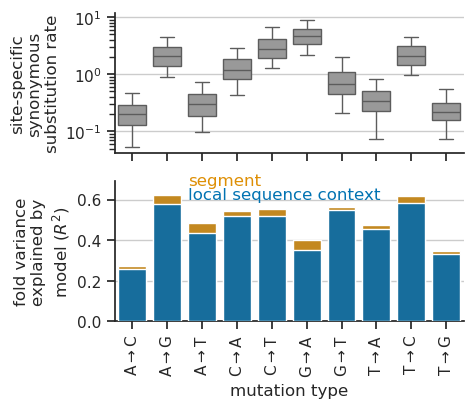

In [4]:
(fig, axs) = plt.subplots(nrows=2, figsize=[4.5,4], sharex=True)

# Plot distributions of rates
all_syn_rates = all_rates_df[all_rates_df['mut_class'] == 'synonymous']
print(len(all_syn_rates), 'mutations')
sns.boxplot(
    x='mut_type_arrow', y='rate', data=all_syn_rates, showfliers=False, whis=(5,95),
    color='0.6', ax=axs[0]
)
axs[0].set(yscale='log', ylabel='site-specific\nsynonymous\nsubstitution rate')
axs[0].grid(axis='y')
    
# Plot R^2 values from neutral model
local_context_color = '#0173b2'
segment_color = '#de8f05'
sns.barplot(
    x='mut_type_arrow', y='r2',
    data=model_performance_df[model_performance_df['param_set'] == 'local_context'],
    color=local_context_color, label='local context', zorder=10, ax=axs[1]
)
sns.barplot(
    x='mut_type_arrow', y='r2',
    data=model_performance_df[model_performance_df['param_set'] == 'local_context+global_context'],
    color=segment_color, label='local context + genomic segment', ax=axs[1]
)
axs[1].set(xlabel='mutation type', ylabel='fold variance\nexplained by\nmodel ($R^2)$', ylim=[0,0.69])
axs[1].get_legend().remove()
axs[1].text(
    0.21, 1.06, 'segment',
    transform=axs[1].transAxes, ha='left', va='top',
    color=segment_color
 )
axs[1].text(
    0.21, 0.96, 'local sequence context',
    transform=axs[1].transAxes, ha='left', va='top',
    color=local_context_color
)
axs[1].grid(axis='y')
for tick in axs[1].get_xticklabels():
    tick.set_rotation(90)
sns.despine()
plt.savefig('../results/figures/site_specific_rates_spread.png', dpi=300, bbox_inches='tight')
plt.show()

Compare interquantile ranges of sites-specific mutation rates between influenza and SARS-CoV-2.

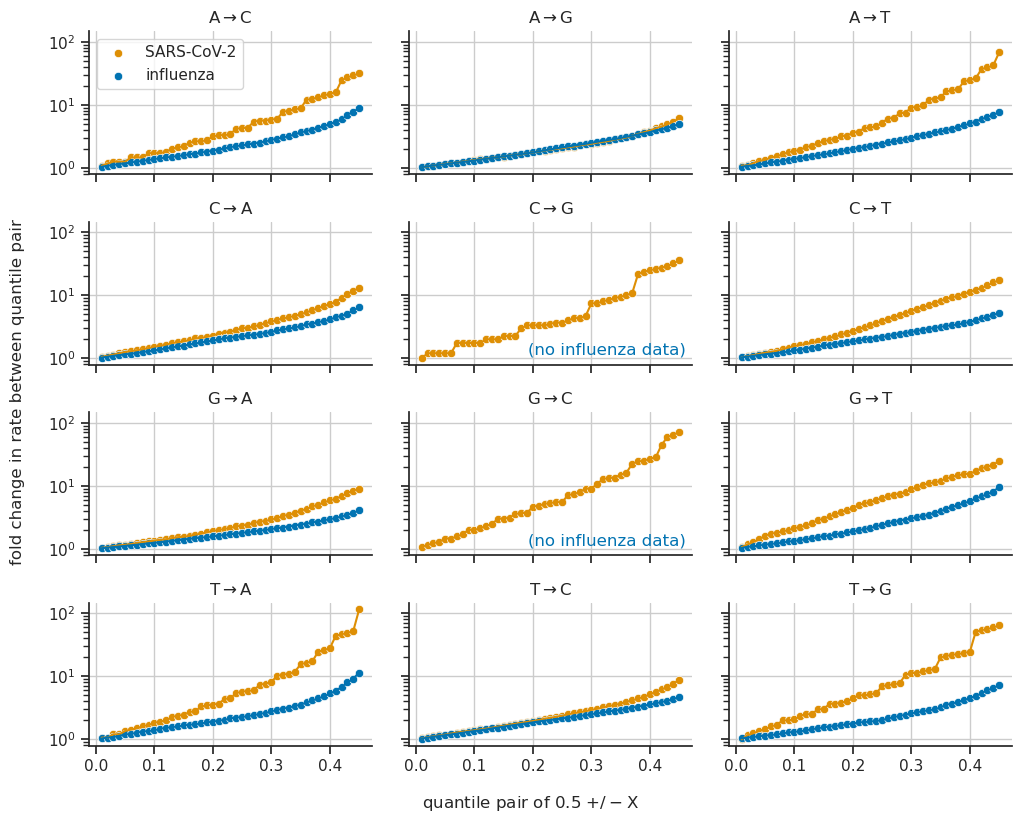

In [5]:
# Get SARS2 data
s2_counts_data = (
    pd.read_csv('https://raw.githubusercontent.com/matsengrp/SARS2-synonymous-mut-rate/refs/heads/main/results/curated_mut_counts.csv')
    .query('mut_class == "synonymous"')
)

# Iterate over mutation types and compute fold changes in counts between quantiles
def plot_fold_changes(diffs, data, metric, min_metric, axs_i, color, label, verbose=False):
    diffs_with_real_values = []
    fold_changes = []
    for diff in diffs:
        lower_bound = data[metric].quantile(0.5-diff)
        upper_bound = data[metric].quantile(0.5+diff)
        if verbose:
            print(lower_bound)
        if lower_bound > min_metric:
            diffs_with_real_values.append(diff)
            fold_changes.append(upper_bound/lower_bound)
    sns.scatterplot(
        x=diffs_with_real_values, y=fold_changes, ax=axs[axs_i], label=label,
        color=color
    )
    sns.lineplot(
        x=diffs_with_real_values, y=fold_changes, ax=axs[axs_i],
        color=color, legend=False
    )

(fig, axs) = plt.subplots(
    ncols=3, nrows=4, sharex=True, sharey=True, figsize=[10,8]
)
axs = axs.reshape(-1)
step = 0.01
diffs = np.arange(step, 0.45+step, step)
mut_types = ['AC', 'AG', 'AT', 'CA', 'CG', 'CT', 'GA', 'GC', 'GT', 'TA', 'TC', 'TG']
for (i, mut_type) in enumerate(mut_types):

    # Plot fold changes for SARS-CoV-2
    s2_data = s2_counts_data[s2_counts_data['mut_type'] == mut_type]
    plot_fold_changes(diffs, s2_data, 'actual_count', 0, i, '#de8f05', 'SARS-CoV-2')

    # Plot fold changes for influenza
    syn_data = all_syn_rates[all_syn_rates['mut_type'] == mut_type]
    if len(syn_data) > 0:
        min_rate = syn_data['min_rate'].unique()
        assert len(min_rate) == 1
        min_rate = min_rate[0]
        plot_fold_changes(diffs, syn_data, 'rate', min_rate, i, '#0173b2', 'influenza', verbose=False)
    else:
        axs[i].text(0.7, 0.1, '(no influenza data)', ha='center', va='center', c='#0173b2', transform=axs[i].transAxes)
    mut_type_arrow = mut_type[0] + '$\\to$' + mut_type[1]
    axs[i].set(title=mut_type_arrow, yscale='log')
    axs[i].grid()
    if i > 0:
        axs[i].get_legend().remove()

fig.text(0.5, -0.02, 'quantile pair of 0.5 $+/-$X', ha='center')
fig.text(-0.02, 0.5, 'fold change in rate between quantile pair', va='center', rotation='vertical')
sns.despine()
plt.tight_layout()
plt.savefig('../results/figures/ms_figures/rate_variation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Compare rates of synonymous, nonsynonymous, and nonsense mutations

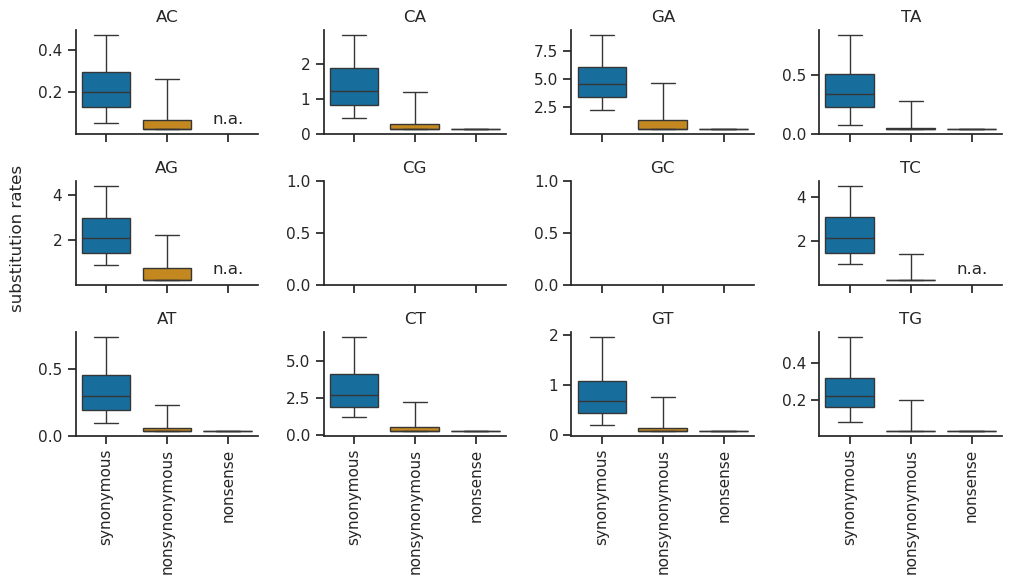

In [6]:
# Define plotting params
mut_class_colors = {
    'synonymous' : '#0173b2',
    'nonsynonymous' : '#de8f05',
    'nonsense' : 'firebrick',
}
order = ['synonymous', 'nonsynonymous', 'nonsense']
(fig, axs) = plt.subplots(nrows=3, ncols=4, sharex=True, sharey=False, figsize=[10,6])
axs = axs.reshape(-1, order='F')

# Plot data for a specific subtype
mut_type_order = ['AC', 'AG', 'AT', 'CA', 'CG', 'CT', 'GA', 'GC', 'GT', 'TA', 'TC', 'TG']
for (i, mut_type) in enumerate(mut_type_order):
    mut_data = all_rates_df[all_rates_df['mut_type'] == mut_type]
    if len(mut_data) == 0:
        axs[i].set(title=mut_type)
        axs[i].tick_params(axis='x', labelrotation=90)
        continue
    sns.boxplot(
        x='mut_class', y='rate', data=mut_data,
        order=order, hue='mut_class', hue_order=order, palette=mut_class_colors,
        whis=(5,95), showfliers=False, ax=axs[i]
    )
    if sum(mut_data['mut_class'] == 'nonsense') == 0:
        axs[i].annotate('n.a.', (0.75, 0.1), xycoords=axs[i].transAxes)
    axs[i].set(title=mut_type, xlabel='', ylabel='')
    axs[i].tick_params(axis='x', labelrotation=90)

fig.text(-0.01, 0.59, 'substitution rates', va='center', rotation='vertical')
plt.tight_layout()
sns.despine()
plt.show()

Plot per-site mutation rates of synonymous and nonsense mutations across the genome.

In [7]:
# Read in the coding length for each segment from the coding-sites tables.
# Match the subtype choice in the plot below (H1 for HA, N1 for NA, 'all' otherwise).
coding_subtype = {
    'PB2': 'all', 'PB1': 'all', 'PA': 'all',
    'HA':  'H1',
    'NP':  'all',
    'NA':  'N1',
    'MP':  'all', 'NS':  'all',
}
coding_lengths = {
    segment: pd.read_csv(
        f'../results/{segment}/{subtype}/coding_sites.csv'
    )['site'].max()
    for segment, subtype in coding_subtype.items()
}
coding_lengths

{'PB2': np.int64(2280),
 'PB1': np.int64(2274),
 'PA': np.int64(2151),
 'HA': np.int64(1701),
 'NP': np.int64(1497),
 'NA': np.int64(1365),
 'MP': np.int64(982),
 'NS': np.int64(838)}

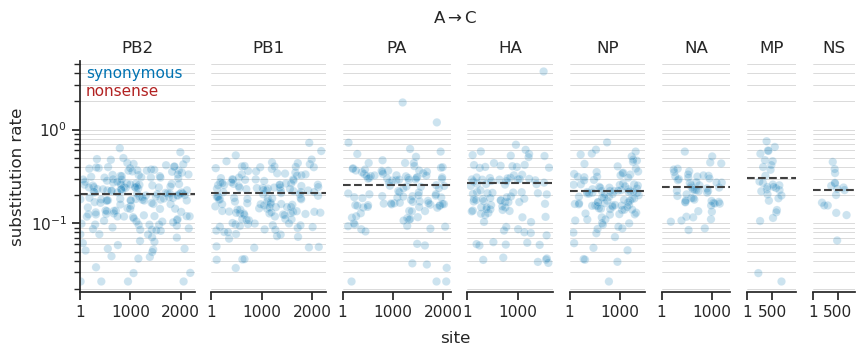

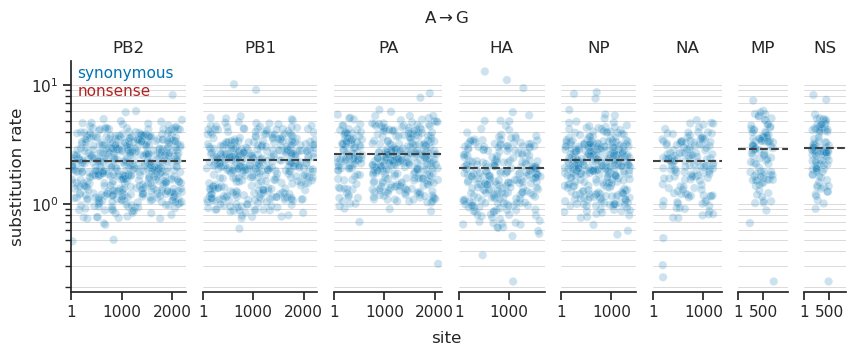

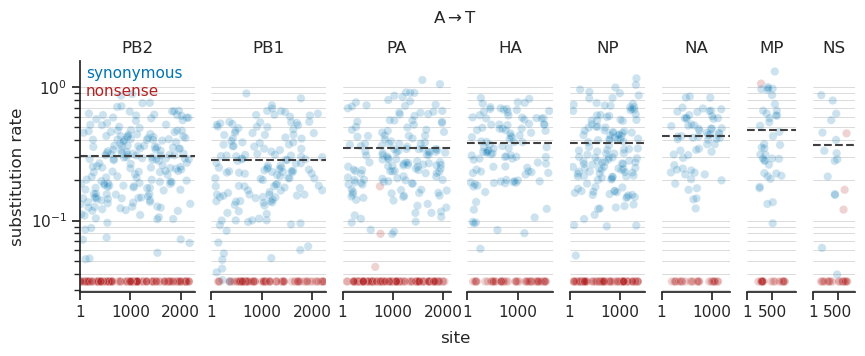

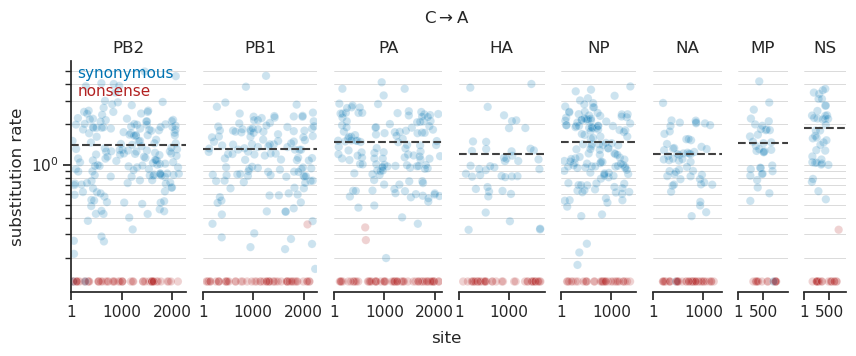

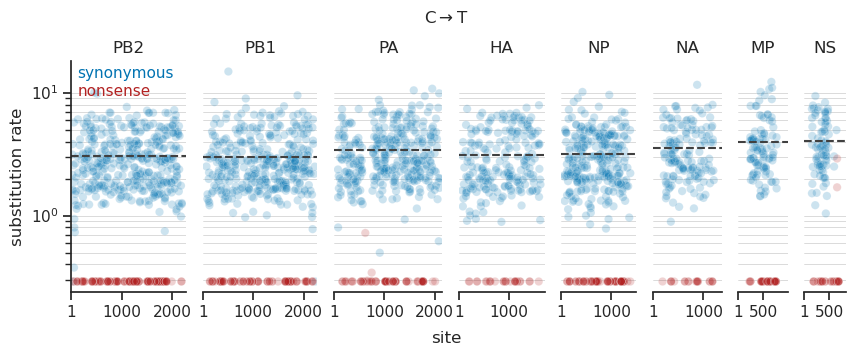

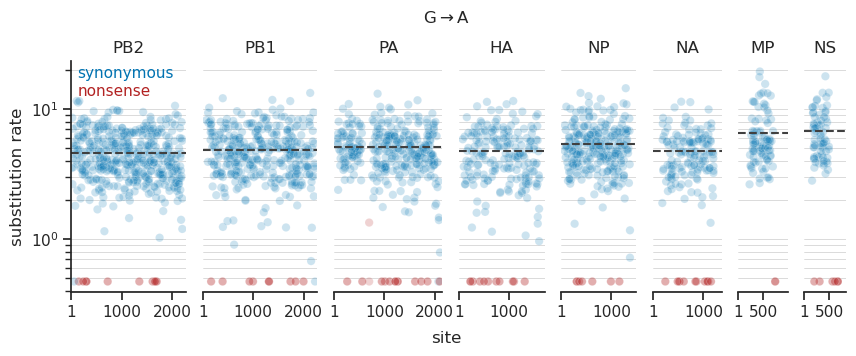

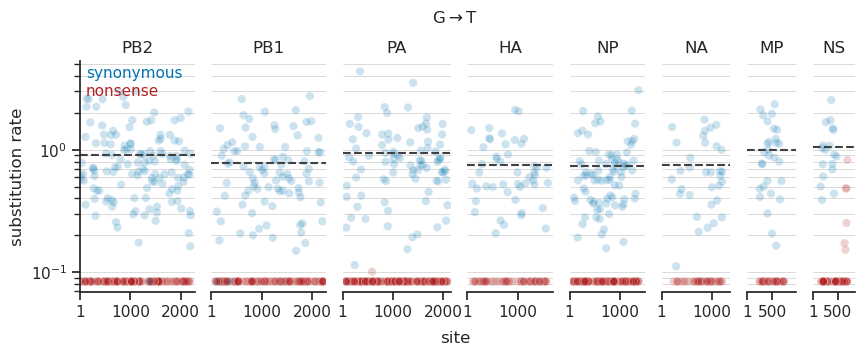

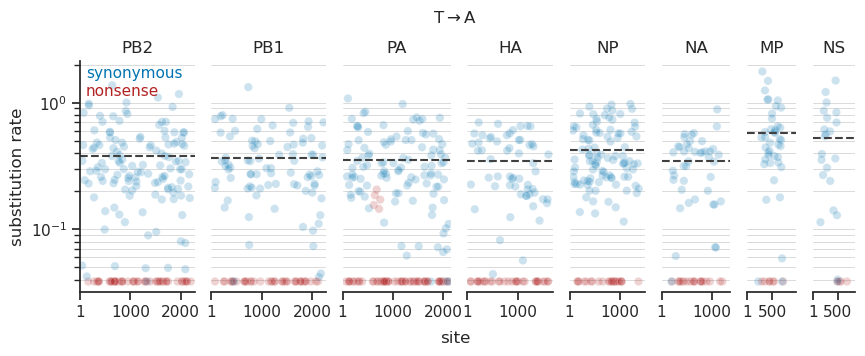

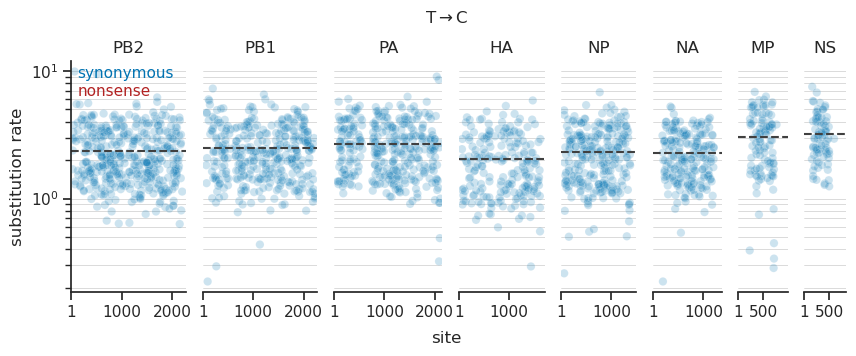

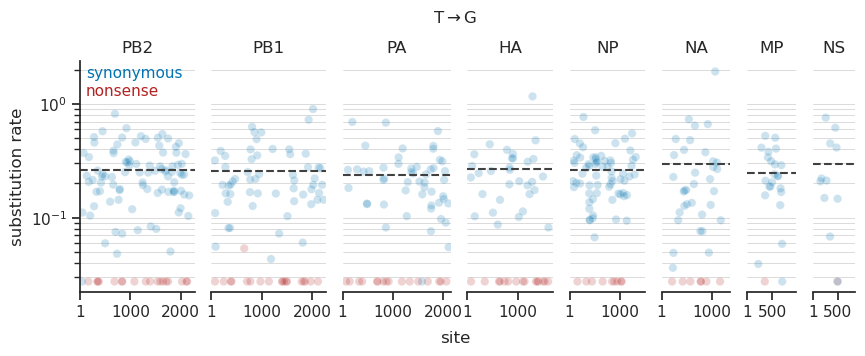

In [8]:
# Get width ratios for plotting segments (use full CDS length, not the max
# non-excluded site, since packaging-signal sites are filtered out of
# all_rates_df but are still part of the coding sequence).
segments = ['PB2', 'PB1', 'PA', 'HA', 'NP', 'NA', 'MP', 'NS']
width_ratios = [coding_lengths[segment] for segment in segments]

# Plot data
mut_classes_to_plot = ['synonymous', 'nonsense']
for (mut_type, mut_type_data) in all_rates_df.groupby('mut_type'):

    # if mut_type != 'CT':
    #     continue

    (fig, axs) = plt.subplots(
        ncols=len(segments), sharey=True, figsize=[10, 3],
        gridspec_kw={'width_ratios': width_ratios}
    )
    for (i, segment) in enumerate(segments):
        seg_len = coding_lengths[segment]
        data = mut_type_data[
            (mut_type_data['subtype'].isin(['all', 'H1', 'N1'])) &
            (mut_type_data['mut_class'].isin(mut_classes_to_plot)) &
            (mut_type_data['segment'] == segment)
        ].copy()
        if len(data) == 0:
            axs[i].set(title=segment)
            axs[i].set_xlim(1, seg_len)
            axs[i].grid(axis='y', which='both', lw=0.5)
            sns.despine(left=True, ax=axs[i])
            continue
        sns.scatterplot(
            x='site', y='rate', data=data, ax=axs[i], alpha=0.2,
            hue='mut_class', palette=mut_class_colors
        )
        syn_data = data[data['mut_class'] == 'synonymous']
        axs[i].axhline(syn_data['rate'].mean(), ls='--', color='0.25')
        axs[i].grid(axis='y', which='both', lw=0.5)
        axs[i].set(title=segment, yscale='log', xlabel='')
        axs[i].set_xlim(1, seg_len)
        if seg_len < 1000:
            axs[i].set_xticks([1, 500])
        elif seg_len < 2000:
            axs[i].set_xticks([1, 1000])
        else:
            axs[i].set_xticks([1, 1000, 2000])
        axs[i].get_legend().remove()
        if i > 0:
            axs[i].tick_params(axis='y', which='both', left=False, labelleft=False)
            sns.despine(left=True, ax=axs[i])
        else:
            sns.despine(ax=axs[i])
        # if segment in ['MP', 'NS']:
        #     axs[i].set(xticks=[0, 500])

    for (j, mut_class) in enumerate(mut_classes_to_plot):
        axs[0].text(
            0.05, 0.98 - j * 0.08, mut_class,
            transform=axs[0].transAxes,
            ha='left', va='top',
            color=mut_class_colors[mut_class],
            fontsize=11
        )

    axs[0].set(ylabel='substitution rate')
    fig.text(0.5, -0.06, 'site', ha='center')
    plt.suptitle(mut_type[0]+r'$\rightarrow$'+mut_type[1], y=1.05, fontsize=12)
    if mut_type == 'CT':
        plt.savefig('../results/figures/mut_rates_' + mut_type[0] + '_' + mut_type[1] + '.png', dpi=300, bbox_inches='tight')
    plt.show()

## Examine the impact of genomic segment on synonymous mutation rates

Compute the fold difference in segment-average mutation rates between the segments with the lowest and highest rates.

In [9]:
fold_diffs_between_segments = (
    segment_wide_rates
    .groupby('mut_type', as_index=False)
    .agg(
        min_rate = ('rate', 'min'),
        max_rate = ('rate', 'max')
    )
    .assign(fold_diff = lambda x: x['max_rate'] / x['min_rate'])
    .sort_values('fold_diff')
)
fold_diffs_between_segments

,mut_type,min_rate,max_rate,fold_diff
10,TC,2.101778,2.830210,1.346579
11,TG,0.246383,0.335091,1.360045
6,GA,4.370816,5.949673,1.361227
5,CT,2.632778,3.700027,1.405370
0,AC,0.219341,0.314332,1.433077
1,AG,2.006153,2.891960,1.441545
3,CA,1.239415,1.839904,1.484494
9,TA,0.329743,0.504505,1.529997
8,GT,0.754824,1.202934,1.593661
2,AT,0.300712,0.488789,1.625441


## Examine the impact of local-sequence context on synonymous mutation rates

Compute median mutation rates as a function of local sequence context.

In [10]:
# Compute global medians
counts_var = 'rate'
global_medians = (
    rates_df[rates_df['mut_class'] == 'synonymous']
    .groupby(['mut_type'], as_index=False)
    .agg(global_median_rates=pd.NamedAgg(column=counts_var, aggfunc='median'))
)

# Compute motif medians for motifs with at least 10 sites, then merge with
# data on global medians
motif_medians = (
    rates_df[rates_df['mut_class'] == 'synonymous']
    .groupby(['mut_type', 'motif'], as_index=False)
    .agg(
        median_rates=pd.NamedAgg(column=counts_var, aggfunc='median'),
        n=pd.NamedAgg(column='motif', aggfunc='count'),
    )
    .query('n >= 10')
    .merge(global_medians, on=['mut_type'])
)
motif_medians['fold_change_from_global'] = motif_medians['median_rates'] / motif_medians['global_median_rates']

motif_medians['mut_type_arrow'] = motif_medians['mut_type'].apply(
    lambda x: x[0]+r'$\rightarrow$'+x[1]
)

Plot site-specific mutation rates as a function of local sequence context.

TG
global median 0.2217404769278414
min median 0.1055388180764774
max median 0.458922165183438
max/min median 4.35


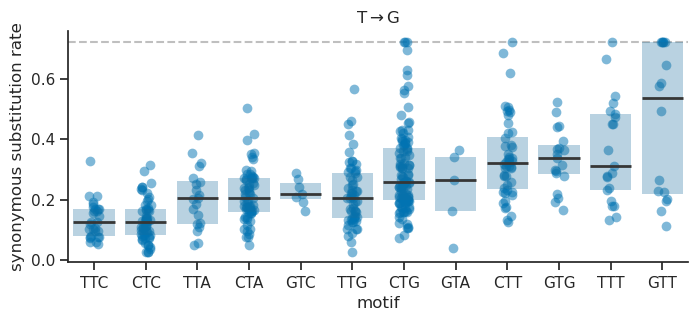

AC
global median 0.2006648776384828
min median 0.0904288179281256
max median 0.28141483830222314
max/min median 3.11


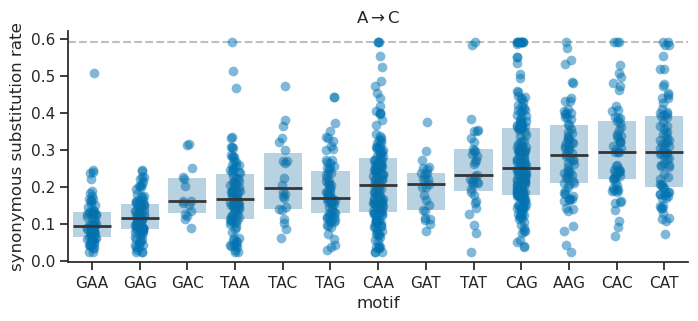

TA
global median 0.33573057527138905
min median 0.1101072107902472
max median 0.6549253944398303
max/min median 5.95


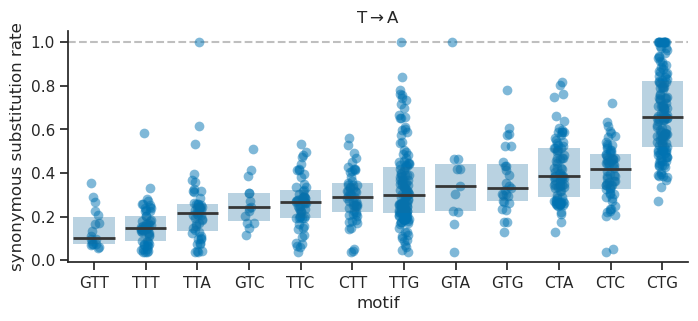

AT
global median 0.29785768649044897
min median 0.1492676056338028
max median 0.5910908845443856
max/min median 3.96


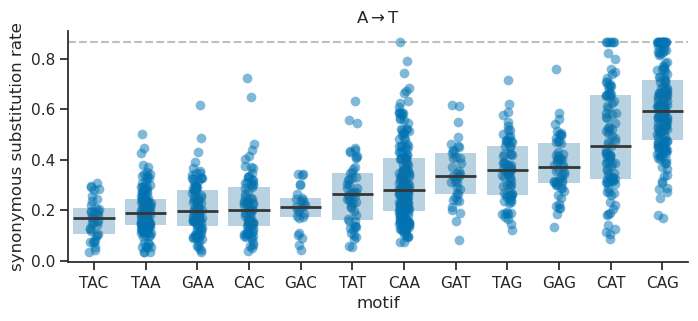

TC
global median 2.1162368724913403
min median 1.123508910510613
max median 3.671159029649596
max/min median 3.27


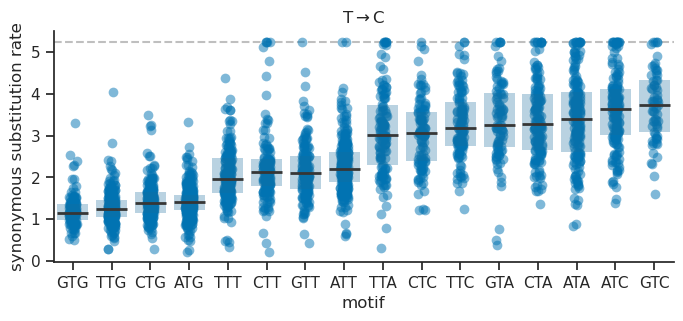

AG
global median 2.092391664128306
min median 1.0876760895817792
max median 3.9158955040537218
max/min median 3.6


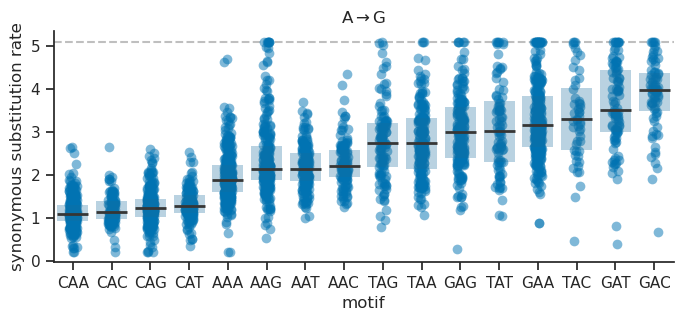

CT
global median 2.72581837630366
min median 1.6295944017936
max median 5.963963150289017
max/min median 3.66


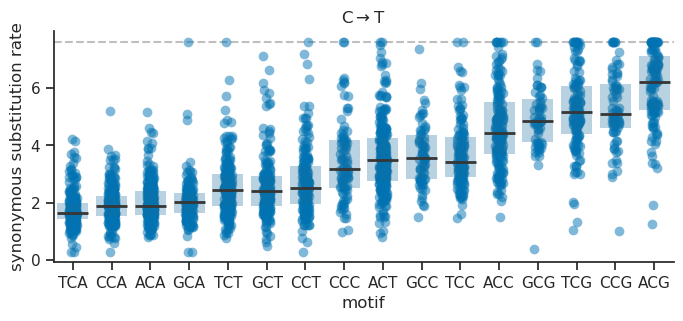

GA
global median 4.590711189650794
min median 2.9975143311334844
max median 7.416423502357782
max/min median 2.47


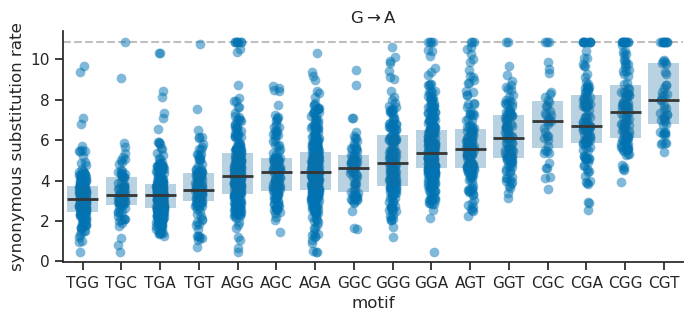

CA
global median 1.2089158922144416
min median 0.527628316099752
max median 2.210202761000863
max/min median 4.19


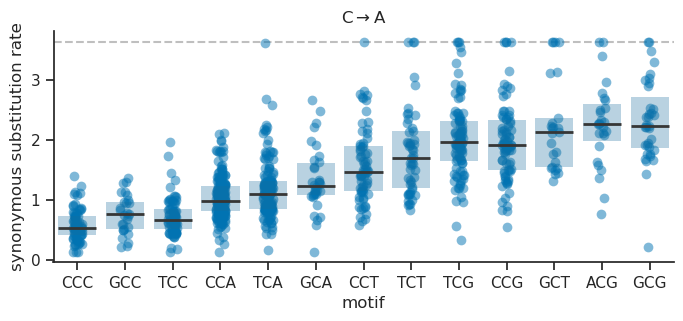

GT
global median 0.6833677045853566
min median 0.2878392044496882
max median 1.4616765973901054
max/min median 5.08


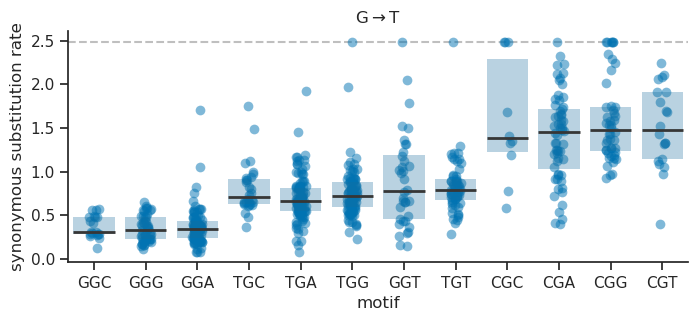

CG
No data

GC
No data



In [11]:
counts_var = 'rate'
mut_types = [
    'TG', 'AC',
    'TA', 'AT', 
    'TC', 'AG',
    'CT', 'GA',
    'CA', 'GT',
    'CG', 'GC',
]
for mut_type in mut_types:

    # Get data for mutation type
    print(mut_type)
    data = all_syn_rates[all_syn_rates['mut_type'] == mut_type].copy()
    if len(data) == 0:
        print("No data\n")
        continue
    quantile_ceiling = data[counts_var].quantile(0.98)
    data[counts_var] = data[counts_var].clip(upper=quantile_ceiling)
    global_median = data[data['mut_class'] == 'synonymous'][counts_var].median()
    motif_medians_data = motif_medians[motif_medians['mut_type'] == mut_type]

    # Report stats
    print('global median', global_median)
    print('min median', motif_medians_data['median_rates'].min())
    print('max median', motif_medians_data['median_rates'].max())
    print('max/min median', round(motif_medians_data['median_rates'].max()/motif_medians_data['median_rates'].min(), 2))

    # Sort motifs by their meian, then plot the distribution of counts for each motif
    data = data.merge(motif_medians_data[['mut_type', 'motif', 'median_rates']], on=['mut_type', 'motif'], how='right')
    data.sort_values('median_rates', inplace=True)
    plt.figure(figsize=[8,3])
    sns.boxplot(
        x='motif', y=counts_var, data=data,
        color=mut_class_colors['synonymous'],
        showfliers=False, whis=0,
        linewidth=0,
        medianprops={"linewidth": 2},
        boxprops={'alpha':.3},
        zorder=10,
    )
    sns.stripplot(
        x='motif', y=counts_var, data=data,
        color=mut_class_colors['synonymous'],
        dodge=True, alpha=0.5, s=7
    )
    #plt.axhline(global_median, c='0.75', ls='--')
    plt.axhline(quantile_ceiling, c='0.75', ls='--')
    sns.despine()
    plt.title(mut_type[0]+r'$\rightarrow$'+mut_type[1])
    plt.ylabel('synonymous substitution rate')
    if mut_type == 'CT':
        plt.savefig('../results/figures/CT_motif_specific_rates.png', dpi=300, bbox_inches='tight')
    plt.show()

Plot the distribution of motif-level rates

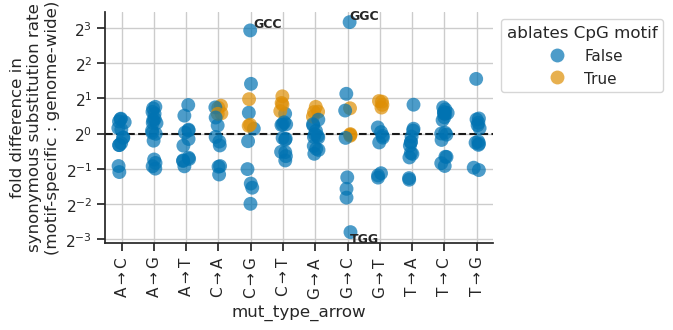

,mut_type,motif,host,actual_count,evo_opp,rate,genome_wide_rate,mut_type_arrow,fold_change,ablates_cg
103,GC,GGC,all,532,887.149984,0.599673,0.066497,G$\to$C,9.018053,False
59,CG,GCC,all,440,1126.436920,0.390612,0.051006,C$\to$G,7.658193,False
157,TG,GTT,all,930,1147.759214,0.810274,0.275278,T$\to$G,2.943479,False
61,CG,GCT,all,139,1020.381269,0.136224,0.051006,C$\to$G,2.670747,False
105,GC,GGT,all,220,1507.620841,0.145925,0.066497,G$\to$C,2.194466,False


,mut_type,motif,host,actual_count,evo_opp,rate,genome_wide_rate,mut_type_arrow,fold_change,ablates_cg
108,GC,TGG,all,37,3880.327875,0.009535,0.066497,G$\to$C,0.143394,False
54,CG,CCA,all,106,8292.321151,0.012783,0.051006,C$\to$G,0.250617,False
102,GC,GGA,all,73,3874.592718,0.018841,0.066497,G$\to$C,0.283332,False
106,GC,TGA,all,110,4909.721931,0.022405,0.066497,G$\to$C,0.336926,False
62,CG,TCA,all,61,3472.914078,0.017565,0.051006,C$\to$G,0.344363,False


In [12]:
# Get genome-wide syn mut rates for all hosts
genome_wide_data = (
    genome_wide_rates[
        (genome_wide_rates['host'] == 'all') &
        (genome_wide_rates['mut_class'] == 'synonymous')
    ][['mut_type', 'rate', 'mut_type_arrow']]
    .rename(columns={'rate': 'genome_wide_rate'})
)

# Merge with motif-level genome-wide rates
data = (
    motif_level_genome_wide_rates[
        (motif_level_genome_wide_rates['host'] == 'all')
    ] # [['mut_type', 'motif', 'rate']]
    .merge(genome_wide_data, validate='many_to_one')
    .assign(fold_change=lambda x: x['rate'] / x['genome_wide_rate'])
)

# Add column indicating whether mutation ablates a CG motif
c_mut_ablates_cg_motifs = data[
    (data['mut_type'].str.startswith('C')) &
    (data['motif'].str.endswith('CG'))
][['mut_type', 'motif']].copy()

g_mut_ablates_cg_motifs = data[
    (data['mut_type'].str.startswith('G')) &
    (data['motif'].str.startswith('CG'))
][['mut_type', 'motif']].copy()

ablates_cg_motifs = pd.concat([c_mut_ablates_cg_motifs, g_mut_ablates_cg_motifs], ignore_index=True)
ablates_cg_motifs['ablates_cg'] = True

data = data.merge(ablates_cg_motifs, how='outer').fillna({'ablates_cg': False})

# Plot data
plt.figure(figsize=[5,3])
ax = sns.stripplot(
    x='mut_type_arrow', y='fold_change', data=data,
    hue='ablates_cg', size=10, alpha=0.7,
)

# Annotate motifs with extreme fold changes
extreme_data = data[(data['fold_change'] > 4) | (data['fold_change'] < 0.25)].copy()
x_levels = list(data['mut_type_arrow'].drop_duplicates())
x_lookup = {label: i for (i, label) in enumerate(x_levels)}
for _, row in extreme_data.iterrows():
    y_offset = 4 if row['fold_change'] >= 1 else -6
    va = 'bottom' if row['fold_change'] >= 1 else 'top'
    ax.annotate(
        row['motif'],
        xy=(x_lookup[row['mut_type_arrow']], row['fold_change']),
        xytext=(12, 0),
        textcoords='offset points',
        ha='center',
        va=va,
        fontsize=9,
        fontweight='bold'
    )

plt.axhline(1, ls='--', c='k')
plt.ylabel('fold difference in\nsynonymous substitution rate\n(motif-specific : genome-wide)')
plt.xticks(rotation=90)
plt.yscale('log', base=2)

# Update legend title
plt.legend(title='ablates CpG motif', bbox_to_anchor=(1,1))

plt.grid()
sns.despine()
plt.savefig('../results/figures/ms_figures/motif_rate_variation.png', dpi=300, bbox_inches='tight')
plt.show()

display(data.sort_values('fold_change', ascending=False).head(5))
display(data.sort_values('fold_change', ascending=True).head(5))

Compute correlation in motif-specific rates between complement mutation types.

['TG', 'AC']
r = 0.891
m = 0.981 b = 0.034


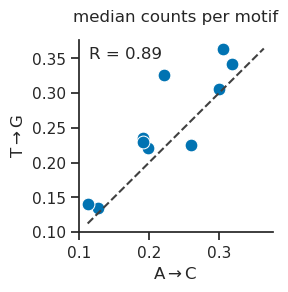

['TA', 'AT']
r = 0.942
m = 0.915 b = 0.093


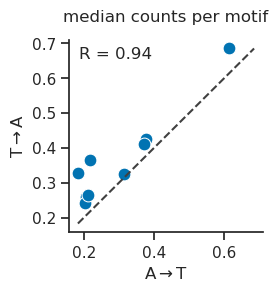

['TC', 'AG']
r = 0.976
m = 0.996 b = 0.119


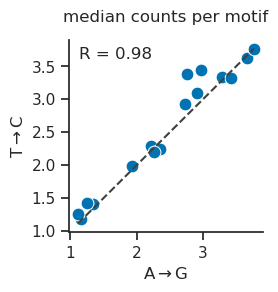

['CT', 'GA']
r = 0.988
m = 0.873 b = -1.125


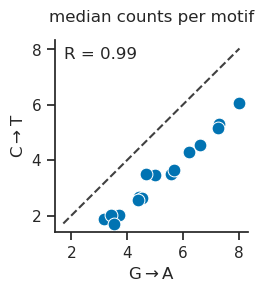

['CA', 'GT']
r = 0.986
m = 1.27 b = 0.193


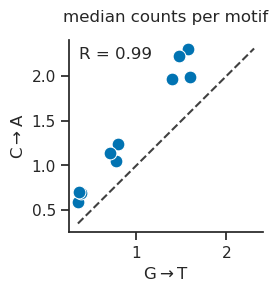

['CG', 'GC']
r = 0.994
m = 0.621 b = 0.021


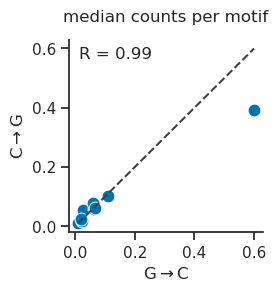

In [13]:
# Add a column giving a reference motif that is the motif for mutation types
# away from T or C, but the reverse-complement motif for mutation types
# away from A or G, allowing for comparison of reverse-complement mutation types
def get_ref_motif(mut_type, motif):
    if mut_type[0] in ['A', 'G']:
        return str(Seq(motif).reverse_complement())
    else:
        return motif
motif_level_genome_wide_rates['ref_motif'] = motif_level_genome_wide_rates.apply(
    lambda row: get_ref_motif(row['mut_type'], row['motif']), axis=1
)

# Plot correlations for each pair
mut_type_pairs = [
    ['TG', 'AC'],
    ['TA', 'AT'],
    ['TC', 'AG'],
    ['CT', 'GA'],
    ['CA', 'GT'],
    ['CG', 'GC'],
]
mirror_metadata = {}
for mut_type_pair in mut_type_pairs:
    data = (
        motif_level_genome_wide_rates[
            (motif_level_genome_wide_rates['host'] == 'all') &
            (motif_level_genome_wide_rates['mut_type'].isin(mut_type_pair))
        ]
        .pivot(index='ref_motif', columns='mut_type', values='rate')
        .dropna()
    )
    if len(data) == 0:
        print(f'No data for pair {mut_type_pair}\n')
        continue
    plt.figure(figsize=[2.5, 2.5])
    x = mut_type_pair[1]
    y = mut_type_pair[0]
    sns.scatterplot(x=x, y=y, data=data, s=85, alpha=1.0)
    r = data[x].corr(data[y])
    (m, b) = np.polyfit(data[x], data[y], 1)
    plt.annotate(f'R = {round(r, 2)}', [0.05, 0.9], xycoords='axes fraction')
    mirror_metadata[mut_type_pair[0]] = [round(r, 4), round(m, 2)]
    print(mut_type_pair)
    print('r =', round(r, 3),)
    print('m =', round(m, 3), 'b =', round(b, 3))
    min_val = data.min().min()
    max_val = data.max().max()
    plt.plot([min_val, max_val], [min_val, max_val], ls='--', c='0.25')
    plt.xlabel(mut_type_pair[1][0]+r'$\rightarrow$'+mut_type_pair[1][1])
    plt.ylabel(mut_type_pair[0][0]+r'$\rightarrow$'+mut_type_pair[0][1])
    plt.title('median counts per motif', y=1.05)
    sns.despine()
    plt.show()

## Compare patterns related to local-sequence context between influenza and SARS-CoV-2

Make a dataframe with motif-specific rates.

In [14]:
# Read in SARS2 motif rates
s2_motif_rates = (
    pd.read_csv('../data/haddox_2025/motif_medians.csv')
    .rename(columns={'fold_change_from_global':'rate'})
    [['mut_type', 'motif', 'rate']]
    .assign(virus='SARS-CoV-2')
)

# Concatenate with influenza motif rates
flu_motif_rates = (
    motif_level_genome_wide_rates[
        motif_level_genome_wide_rates['host'].isin(['human', 'avian', 'swine'])
    ]
    .assign(virus=lambda x: x['host'] + ' influenza')
)
virus_motif_rates = pd.concat([flu_motif_rates, s2_motif_rates])
virus_motif_rates.head()

,mut_type,motif,host,actual_count,evo_opp,rate,ref_motif,virus
1,AC,AAG,avian,599.0,1627.821476,0.367976,CTT,avian influenza
2,AC,AAG,human,1459.0,4861.476402,0.300115,CTT,human influenza
3,AC,AAG,swine,147.0,456.519675,0.322001,CTT,swine influenza
5,AC,CAA,avian,909.0,3022.330089,0.300761,TTG,avian influenza
6,AC,CAA,human,1949.0,8044.657459,0.242273,TTG,human influenza


For each mutation type, compute the correlation in motif-specific rates between viruses.

In [15]:
# Loop over mut types and compute correlations in motif rates between groups of viruses
ref_virus = 'human influenza'
corr_dict = defaultdict(list)

for mut_type in mut_types:

    # if mut_type in ['CG', 'GC']:
    #     continue

    # Compute motif-specific mutation rates and merge with SARS2 motif rates
    data = (
        virus_motif_rates[virus_motif_rates['mut_type'] == mut_type]
        .pivot_table(index='motif', columns='virus', values='rate')
        .reset_index()
        .sort_values(ref_virus)
        .set_index('motif')
    )

    # Compute correlation with reference subtype
    for col in data.columns:
        x = data[ref_virus]
        y = data[col]
        nas = np.logical_or(x.isnull(), y.isnull())
        # print(col, nas)
        if sum(~nas) < 4:
            continue
        (r, p) = scipy.stats.pearsonr(x[~nas], y[~nas])
        corr_dict['virus'].append(col)
        corr_dict['mut_type'].append(mut_type)
        corr_dict['mut_type_arrow'].append(mut_type[0]+r'$\rightarrow$'+mut_type[1])
        corr_dict['r2'].append(r**2)
        corr_dict['r'].append(r)
        corr_dict['p'].append(p)

corr_df = pd.DataFrame(corr_dict)
corr_df.dropna(inplace=True)
corr_df

,virus,mut_type,mut_type_arrow,r2,r,p
0,SARS-CoV-2,TG,T$\rightarrow$G,0.173156,-0.416120,1.784712e-01
1,avian influenza,TG,T$\rightarrow$G,0.971652,0.985724,4.559349e-09
2,human influenza,TG,T$\rightarrow$G,1.000000,1.000000,0.000000e+00
3,swine influenza,TG,T$\rightarrow$G,0.922815,0.960633,6.969739e-07
4,SARS-CoV-2,AC,A$\rightarrow$C,0.181281,-0.425771,1.468969e-01
5,avian influenza,AC,A$\rightarrow$C,0.927665,0.963154,1.292807e-07
6,human influenza,AC,A$\rightarrow$C,1.000000,1.000000,0.000000e+00
7,swine influenza,AC,A$\rightarrow$C,0.860515,0.927640,4.938825e-06
8,SARS-CoV-2,TA,T$\rightarrow$A,0.426286,0.652906,2.134480e-02
9,avian influenza,TA,T$\rightarrow$A,0.922751,0.960600,6.998811e-07


Plot correlations of motif-specific rates between subtypes.

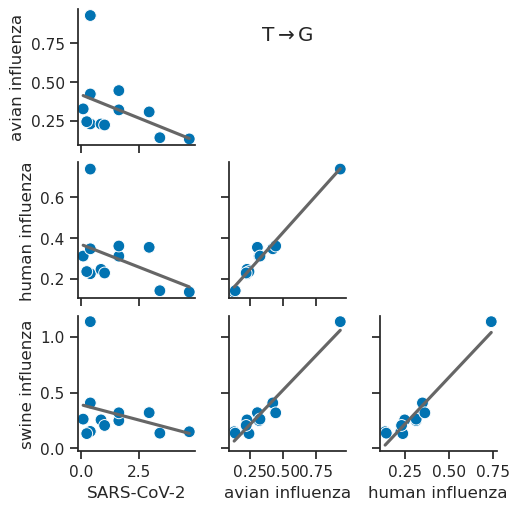

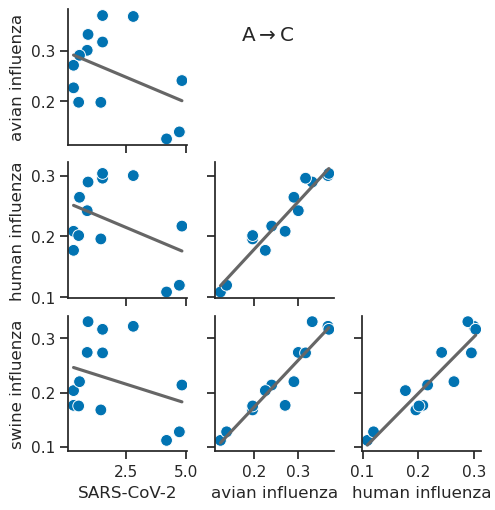

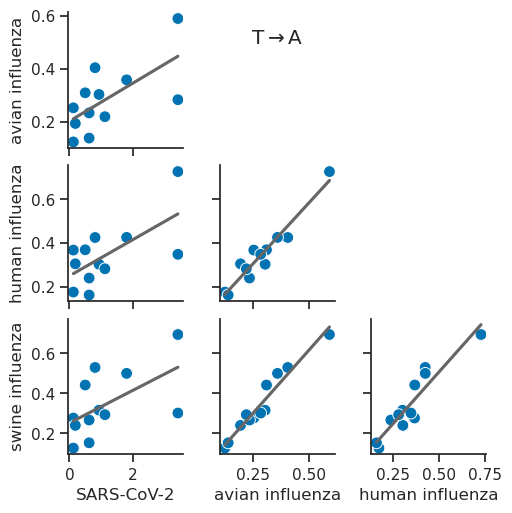

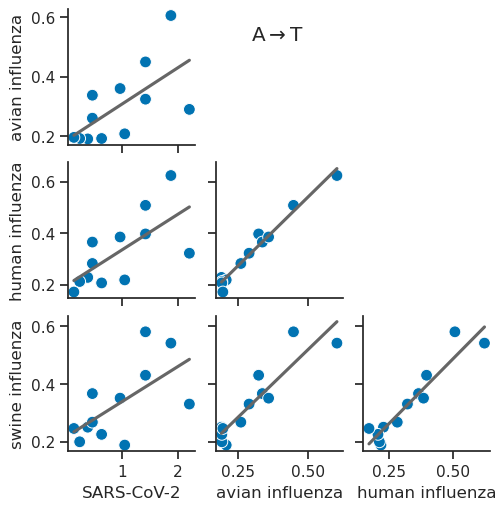

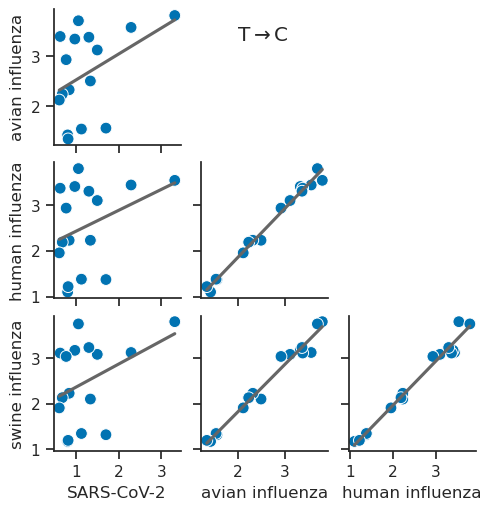

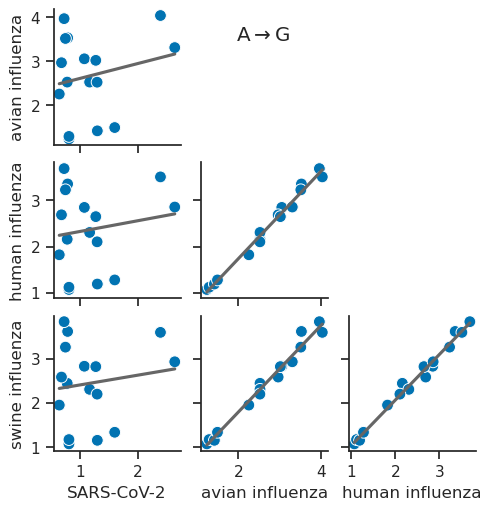

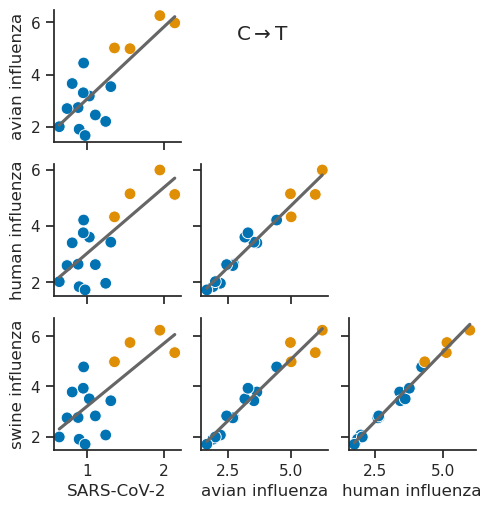

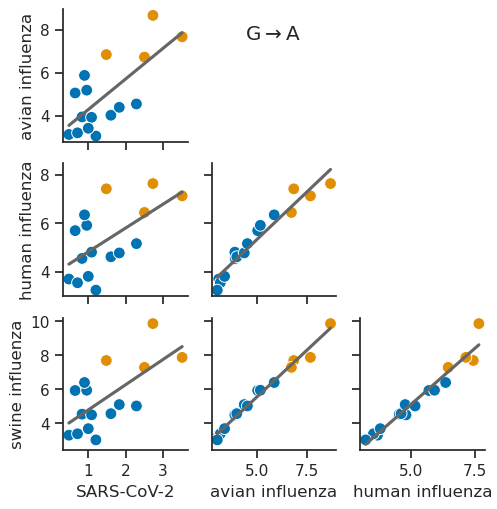

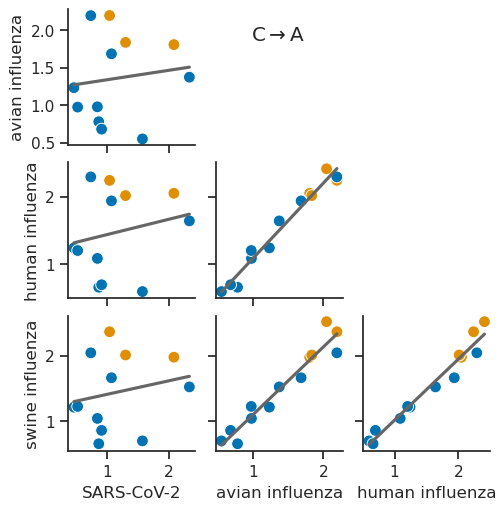

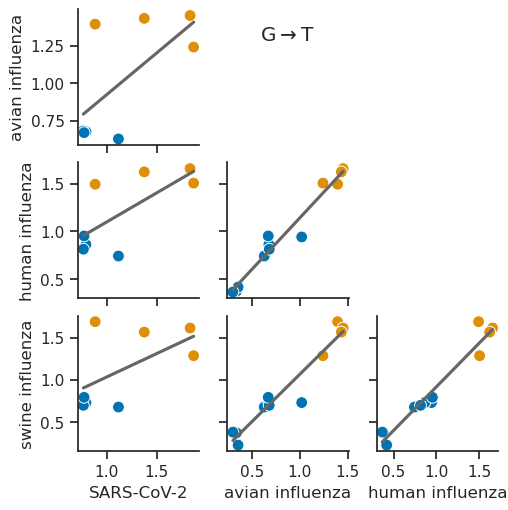

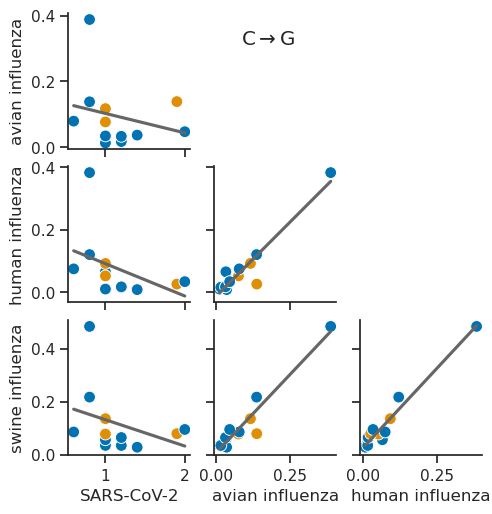

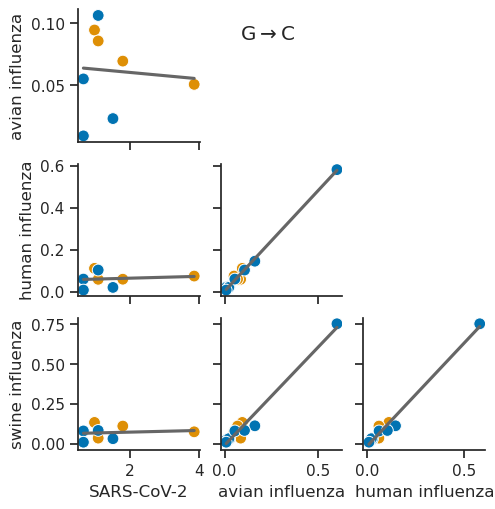

In [16]:
mut_types = [
    'TG', 'AC',
    'TA', 'AT', 
    'TC', 'AG',
    'CT', 'GA',
    'CA', 'GT',
    'CG', 'GC',
]

def mut_ablates_cg(mut_type, motif):
    if mut_type[0] == 'C' and motif.endswith('CG'):
        return True
    if mut_type[0] == 'G' and motif.startswith('CG'):
        return True
    return False

ablates_cg_palette = {False: '#0173b2', True: '#de8f05'}

for mut_type in mut_types:
    data = (
        virus_motif_rates[virus_motif_rates['mut_type'] == mut_type]
        .pivot_table(index='motif', columns='virus', values='rate')
    )
    data = data.assign(
        ablates_cg=[mut_ablates_cg(mut_type, m) for m in data.index]
    )
    viruses = [c for c in data.columns if c != 'ablates_cg']

    # Single overall regression line per pair (no hue split); scatter is
    # added below so that points can be colored by ablates_cg.
    g = sns.pairplot(
        data, vars=viruses, corner=True, kind='reg',
        plot_kws={'ci': None, 'scatter': False, 'line_kws': {'color': '0.4'}},
        diag_kind=False, height=1.7,
    )
    for i, y_var in enumerate(viruses):
        for j, x_var in enumerate(viruses):
            if j >= i:
                continue
            sns.scatterplot(
                data=data, x=x_var, y=y_var,
                hue='ablates_cg', palette=ablates_cg_palette,
                s=72, ax=g.axes[i, j], legend=False,
            )
    for i in range(len(viruses)):
        g.axes[i, i].set_visible(False)
    plt.suptitle(mut_type[0]+r'$\rightarrow$'+mut_type[1], x=0.43, y=0.72)
    plt.savefig(
        f'../results/figures/motif_specific_rates_pairplot_{mut_type}.png',
        dpi=300, bbox_inches='tight',
    )
    plt.show()

Summarize correlations in a single heatmap.

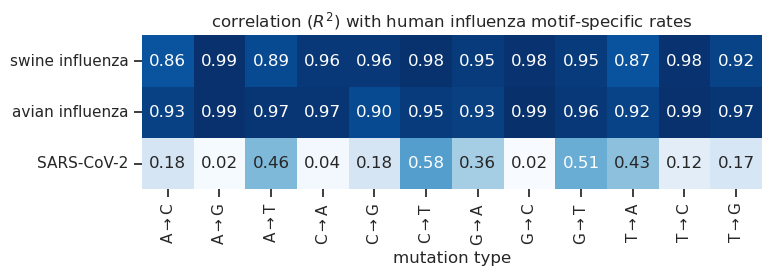

In [17]:
data = (
    corr_df
    .pivot_table(index='virus', columns='mut_type_arrow', values='r2')
    .loc[['swine influenza', 'avian influenza', 'SARS-CoV-2']]
    .clip(lower=0)
)

plt.figure(figsize=[10,2])
sns.heatmap(data, cmap='Blues', annot=True, fmt='.2f')
plt.gcf().axes[-1].set_visible(False) # hide color bar
ax = plt.gca()
ax.patch.set_facecolor('0.5')
plt.title('correlation ($R^2$) with human influenza motif-specific rates')
plt.xticks(rotation=90)
plt.xlabel('mutation type')
plt.ylabel('')
plt.yticks(rotation=0)
plt.savefig('../results/figures/motif_specific_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

## Examine the impact of RNA secondary structure on synonymous mutation rates

Merge reactivity data with rate data, only examining synonymous mutations and only examining sites where the wt nt in the experiment is the same as for the fitness estimate.

In [18]:
reactivity_df = (
    pd.read_csv('../results/shapemap/all_data.csv')
    .rename(columns={'ref_site':'site', 'wt_nt_pos_strand':'wt_nt'})
    .merge(all_syn_rates, on=['segment', 'site', 'wt_nt'])
)
reactivity_df['reactivity'] = reactivity_df['reactivity'].clip(lower=-0.5, upper=2.5)
reactivity_df.head()

,strain,segment,substrate,site,ref_wt_nt,site_pos_strand,wt_nt,reactivity,nt_mut,mut_nt,...,host,evo_opp,rate,exclude_from_mut_rate_analysis,evo_opp_bin,max_site,evo_opp_threshold,unclipped_rate,min_rate,mut_type_arrow
0,A/Puerto_Rico/8/1934,MP,vRNP,761,C,786,C,0.102712,C761T,T,...,all,13.242084,1.661370,False,11.787686,981,3.441437,1.661370,0.290576,C$\rightarrow$T
1,A/Puerto_Rico/8/1934,MP,vRNP,760,C,785,T,0.208115,T760C,C,...,all,70.110317,3.794021,False,61.054023,981,4.455602,3.794021,0.224437,T$\rightarrow$C
2,A/Puerto_Rico/8/1934,MP,vRNP,709,T,734,T,0.443323,T709C,C,...,all,17.871297,0.447645,False,17.782794,981,4.455602,0.447645,0.224437,T$\rightarrow$C
3,A/Puerto_Rico/8/1934,MP,vRNP,709,T,734,T,0.443323,T709C,C,...,all,82.615935,0.338918,False,61.054023,981,4.455602,0.338918,0.224437,T$\rightarrow$C
4,A/Puerto_Rico/8/1934,MP,vRNP,708,T,733,T,0.609835,T708C,C,...,all,100.486210,1.691774,False,92.105532,981,4.455602,1.691774,0.224437,T$\rightarrow$C


For each segment from each strain with experimental data, report the number of sites with estimated rates and experimental measurements.

In [19]:
reactivity_df.groupby(['segment', 'strain'])['site'].nunique()

segment  strain              
MP       A/Puerto_Rico/8/1934    172
         A/Udorn/307/72          171
         A/WSN/1933(H1N1)        172
NP       A/Puerto_Rico/8/1934    462
         A/Udorn/307/72          470
         A/WSN/1933(H1N1)        462
NS       A/Puerto_Rico/8/1934    123
         A/Udorn/307/72          124
         A/WSN/1933(H1N1)        125
PA       A/Puerto_Rico/8/1934    618
         A/Udorn/307/72          638
         A/WSN/1933(H1N1)        625
PB1      A/Puerto_Rico/8/1934    615
         A/Udorn/307/72          740
         A/WSN/1933(H1N1)        615
PB2      A/Puerto_Rico/8/1934    764
         A/Udorn/307/72          773
         A/WSN/1933(H1N1)        762
Name: site, dtype: int64

Plot the correlation between rates and SHAPE-Map reactivities.

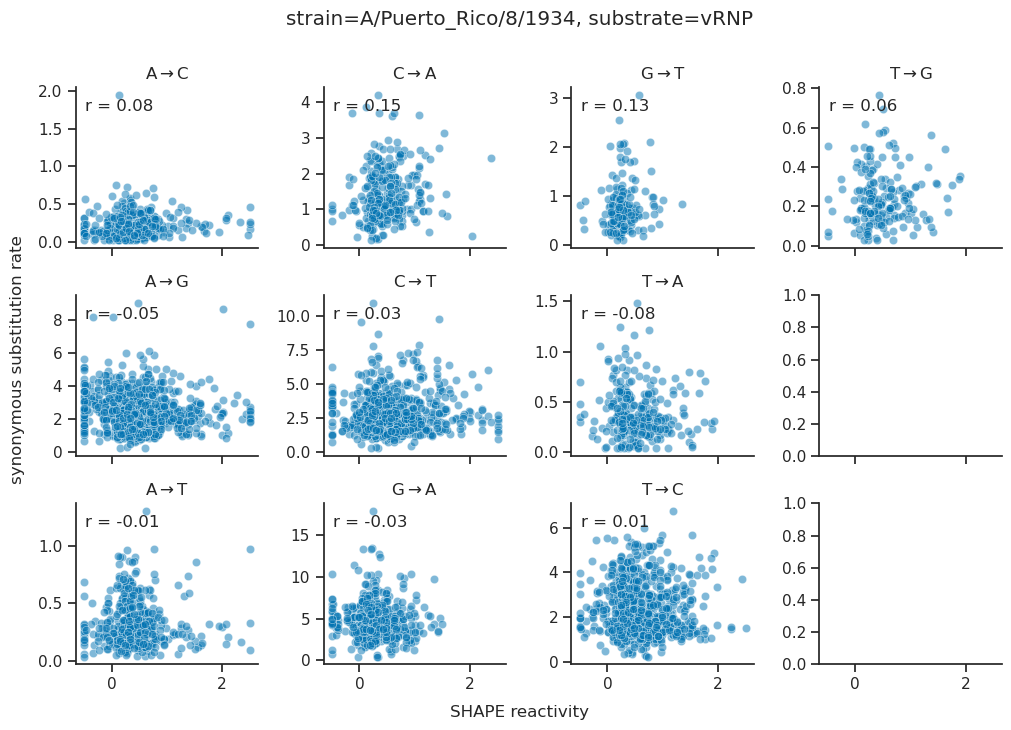

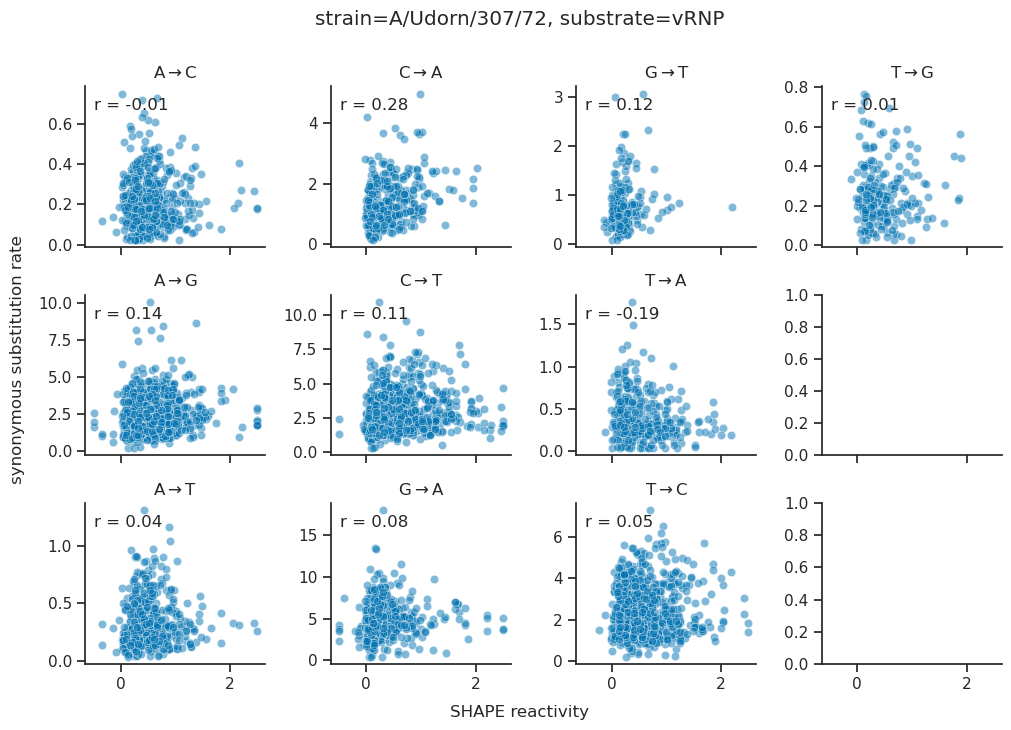

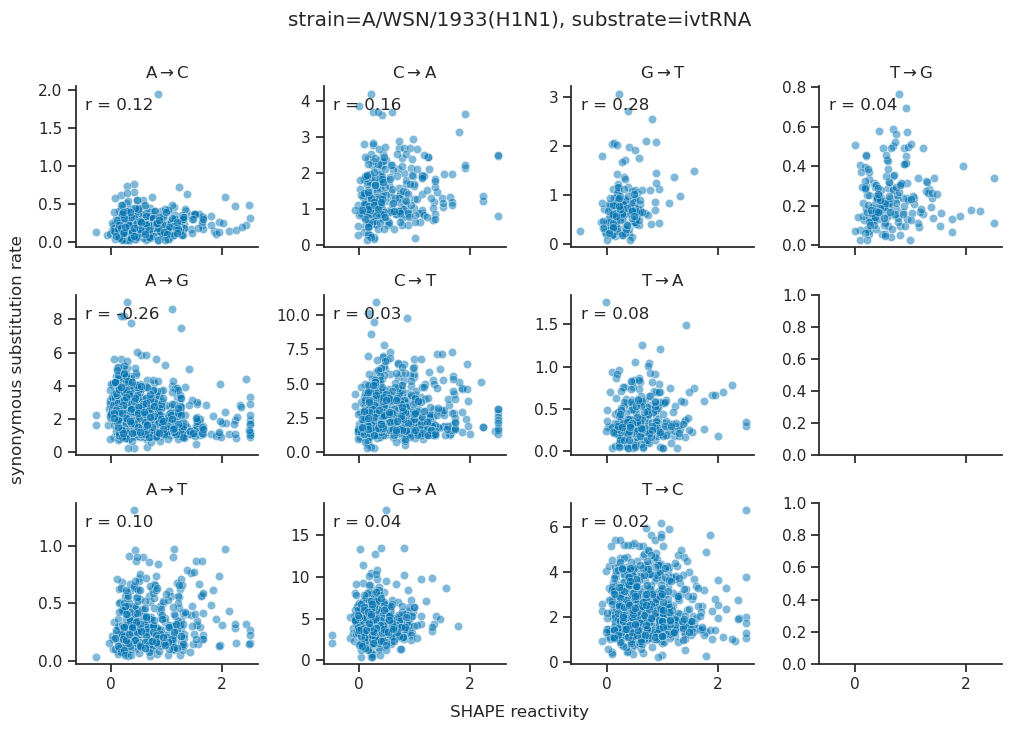

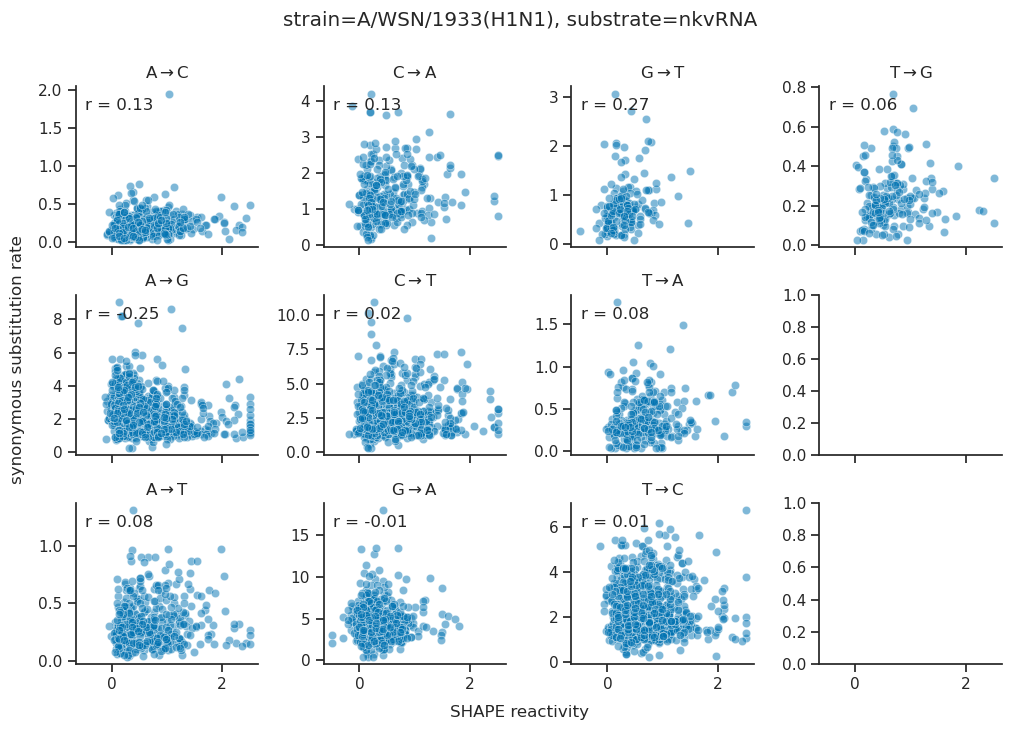

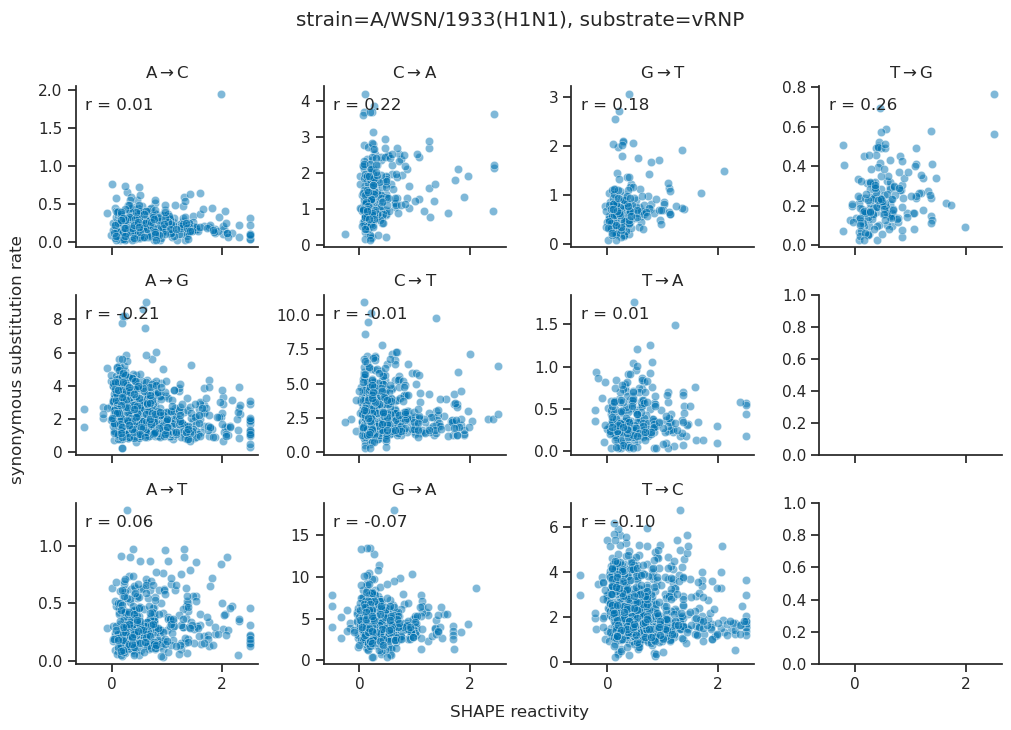

In [20]:
mut_types = sorted(rates_df['mut_type_arrow'].unique())
for group, group_data in reactivity_df.groupby(['strain', 'substrate']):

    # Plot data
    (fig, axs) = plt.subplots(ncols=4, nrows=3, figsize=[10,7], sharex=True)
    axs = axs.reshape(-1, order='F')
    for (i, mut_type) in enumerate(mut_types):
        data = group_data[group_data['mut_type_arrow'] == mut_type]
        sns.scatterplot(x='reactivity', y='rate', data=data, ax=axs[i], alpha=0.5)
        axs[i].set(title=mut_type, xlabel='', ylabel='')
        if len(data) > 1:
            (r, p) = scipy.stats.pearsonr(data['reactivity'], data['rate'])
            axs[i].annotate(text=f'r = {r:.2f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12)

    # Modify plot
    plt.suptitle(f'strain={group[0]}, substrate={group[1]}', y=1)
    fig.text(-0.01, 0.5, 'synonymous substitution rate', va='center', rotation='vertical')
    fig.text(0.5, -0.01, 'SHAPE reactivity', ha='center')
    plt.tight_layout()
    sns.despine()
    if group == ('A/Udorn/307/72', 'vRNP'):
        plt.savefig('../results/figures/ms_figures/rna_ss.png', dpi=300, bbox_inches='tight')
    plt.show()